In [ ]:
import os
import numpy as np
import pandas as pd


def build_turbine(csv_path="turbine_energy.csv", seed=152, verbose=False):
    """Wind-turbine daily energy yield — a nonlinear regression with a skewed target,
    correlated features, an outlier-prone signal and a feature that needs transforming.
    Ideal for residual diagnostics, transforms, regularisation and tree ensembles.

    Features:
      wind_speed_ms        average wind speed (m/s)
      wind_std_ms          gustiness (std of wind speed)
      air_density_kgm3     air density (kg/m^3)
      turbulence_intensity fraction (0-1)
      blade_pitch_deg      blade pitch angle (deg)
      rotor_rpm            rotor speed (rpm)
      ambient_temp_c       ambient temperature (deg C)
      turbine_age_years    age of the turbine (years)
    Target:
      energy_kwh           daily energy produced (kWh) — right-skewed
    """
    rng = np.random.default_rng(seed)
    N = 1600
    wind = np.clip(rng.weibull(2.0, N) * 7.0, 0.5, 26)          # Weibull -> right-skew
    wind_std = np.clip(0.12 * wind + rng.normal(0, 0.3, N), 0.05, None)
    density = np.clip(rng.normal(1.225, 0.04, N), 1.10, 1.35)
    turb = np.clip(rng.normal(0.14, 0.05, N), 0.02, 0.40)
    pitch = np.clip(rng.normal(4, 6, N), -2, 25)
    rpm = np.clip(8 + 0.9 * wind + rng.normal(0, 1.5, N), 4, 30)  # correlated with wind
    temp = rng.normal(15, 9, N).round(1)
    age = rng.uniform(0, 20, N)

    # power ~ density * v^3 up to rated, then flattens; losses from pitch, turbulence, age
    cube = np.minimum(wind, 13) ** 3                              # cubic then saturates near rated
    rated_extra = np.maximum(wind - 13, 0) * 120
    energy = (density * (3.1 * cube + rated_extra)
              - 35 * np.abs(pitch - 2)
              - 1800 * turb
              - 22 * age
              + rng.normal(0, 280, N))
    energy = np.clip(energy, 0, None)
    # a few sensor-glitch outliers
    g = rng.choice(N, 18, replace=False)
    energy[g] = energy[g] * rng.uniform(1.6, 2.4, len(g))

    df = pd.DataFrame({
        "wind_speed_ms": wind.round(2), "wind_std_ms": wind_std.round(2),
        "air_density_kgm3": density.round(3), "turbulence_intensity": turb.round(3),
        "blade_pitch_deg": pitch.round(1), "rotor_rpm": rpm.round(1),
        "ambient_temp_c": temp, "turbine_age_years": age.round(1),
        "energy_kwh": energy.round(1),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        from scipy.stats import skew
        print("turbine:", df.shape)
        print("energy range:", df.energy_kwh.min(), "-", df.energy_kwh.max())
        print("target skew:", round(skew(df.energy_kwh), 2))
        print("corr(wind, energy):", round(df.wind_speed_ms.corr(df.energy_kwh), 3))
        print("corr(wind, rpm):", round(df.wind_speed_ms.corr(df.rotor_rpm), 3))
    return df

if not os.path.exists('turbine_energy.csv'):
    build_turbine(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv('turbine_energy.csv')
TARGET = 'energy_kwh'
features = [c for c in df.columns if c != TARGET]
X = df[features].values; y = df[TARGET].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('shape:', df.shape, '| features:', len(features))
df.head(3)

Generated dataset file.
shape: (1600, 9) | features: 8


,wind_speed_ms,wind_std_ms,air_density_kgm3,turbulence_intensity,blade_pitch_deg,rotor_rpm,ambient_temp_c,turbine_age_years,energy_kwh
0,4.95,0.81,1.238,0.185,-1.2,13.1,2.4,2.7,0.0
1,6.83,0.84,1.265,0.169,-2.0,15.3,12.1,5.9,527.2
2,1.44,0.05,1.225,0.114,-2.0,7.3,26.1,1.2,0.0


baseline RMSE: 1032.5 kWh | R2: 0.727


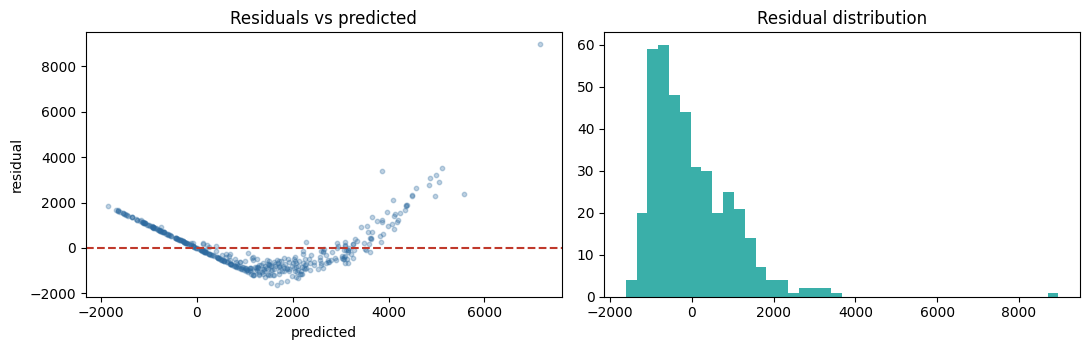

Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. LINEAR BASELINE + RESIDUAL PLOT
# -----------------------------------------------------------
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
resid = y_test - pred
print(f'baseline RMSE: {mean_squared_error(y_test, pred) ** 0.5:.1f} kWh | R2: {r2_score(y_test, pred):.3f}')
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].scatter(pred, resid, s=10, alpha=0.3, color='#2D6A9F')
ax[0].axhline(0, color='#C0392B', ls='--'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('residual')
ax[0].set_title('Residuals vs predicted')
ax[1].hist(resid, bins=40, color='#3AAFA9'); ax[1].set_title('Residual distribution')
plt.tight_layout(); plt.show()
print('Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.')


In [ ]:
from scipy.stats import skew

# -----------------------------------------------------------
# 1. Describe the residual pattern
# -----------------------------------------------------------

# Comment:
# The residuals vs predicted plot shows a clear pattern rather
# than a completely random cloud.
#
# A fan shape may be present if the spread of residuals increases
# as predicted strength increases (heteroscedasticity).
#
# A curved trend is also visible, suggesting the model is missing
# some nonlinear relationship (especially the log(age) effect).
#
# Therefore, the residuals indicate possible nonlinearity and
# non-constant variance.


# -----------------------------------------------------------
# 2. Compute skewness of the target
# -----------------------------------------------------------

target_skew = skew(y)

print(f"Target skewness = {target_skew:.3f}")

if target_skew > 1:
    print("Target is strongly right-skewed.")
elif target_skew > 0:
    print("Target is mildly right-skewed.")
elif target_skew < -1:
    print("Target is strongly left-skewed.")
elif target_skew < 0:
    print("Target is mildly left-skewed.")
else:
    print("Target is approximately symmetric.")

Target skewness = 2.211
Target is strongly right-skewed.


In [ ]:
#Fix it with a transform

# -----------------------------------------------------------
# 🔹 2A. PHYSICS-INFORMED FEATURE TRANSFORM (power ~ wind^3)
# -----------------------------------------------------------
# The residual curve comes from the cubic wind->power law. Add wind^2 and wind^3.
wi = features.index('wind_speed_ms')
def add_wind_poly(M):
    w = M[:, wi:wi + 1]
    return np.hstack([M, w ** 2, w ** 3])
Xtr_aug, Xte_aug = add_wind_poly(X_train), add_wind_poly(X_test)
lin_aug = LinearRegression().fit(Xtr_aug, y_train)
pred_aug = lin_aug.predict(Xte_aug)
print(f'baseline           R2: {r2_score(y_test, pred):.3f}')
print(f'+ wind^2, wind^3   R2: {r2_score(y_test, pred_aug):.3f}')
print('Matching the feature to the physics straightens the relationship.')


baseline           R2: 0.727
+ wind^2, wind^3   R2: 0.935
Matching the feature to the physics straightens the relationship.


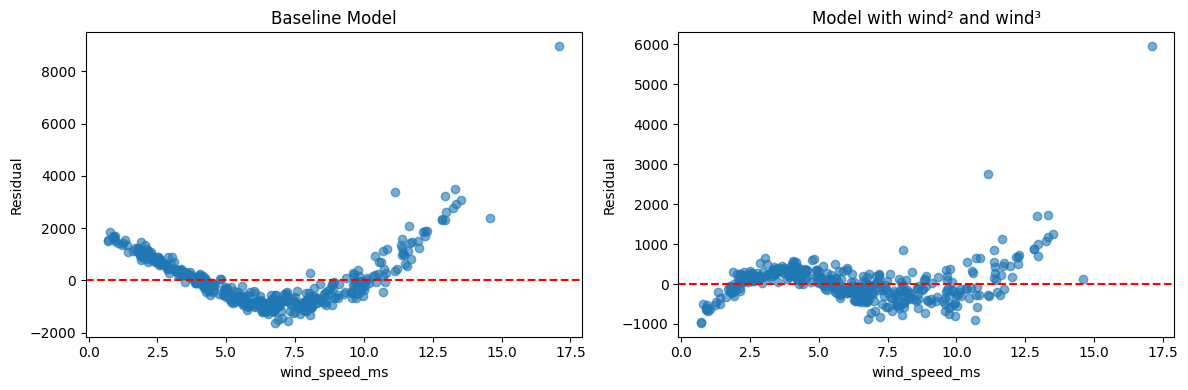

In [ ]:
# -----------------------------------------------------------
# Residuals vs Wind Speed
# -----------------------------------------------------------

import matplotlib.pyplot as plt

# Baseline residuals
baseline_resid = y_test - pred

# Augmented residuals
aug_resid = y_test - pred_aug

# wind_speed_ms column in test set
wind_test = X_test[:, wi]

fig, ax = plt.subplots(1, 2, figsize=(12,4))

# Baseline
ax[0].scatter(wind_test, baseline_resid, alpha=0.6)
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel("wind_speed_ms")
ax[0].set_ylabel("Residual")
ax[0].set_title("Baseline Model")

# Augmented
ax[1].scatter(wind_test, aug_resid, alpha=0.6)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_xlabel("wind_speed_ms")
ax[1].set_ylabel("Residual")
ax[1].set_title("Model with wind² and wind³")

plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------------
# 🔹 3A. COMPARE LINEAR, RIDGE, LASSO, ELASTIC NET
# -----------------------------------------------------------

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

# Function to train and evaluate a model
def score_model(model):

    pipeline = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=2, include_bias=False),
        model
    )

    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)

    return r2_score(y_test, pred)

# Linear Regression
print(
    f'{"LinearRegression":14s} test R2: '
    f'{score_model(LinearRegression()):.3f}'
)

# Ridge, Lasso, Elastic Net
models = [
    ('Ridge', Ridge(alpha=10.0)),
    ('Lasso', Lasso(alpha=1.0, max_iter=10000)),
    ('ElasticNet', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000))
]

for name, model in models:

    r2 = score_model(model)

    print(
        f'{name:14s} test R2: {r2:.3f}'
    )

LinearRegression test R2: 0.908
Ridge          test R2: 0.908
Lasso          test R2: 0.909
ElasticNet     test R2: 0.863


ElasticNet performed worse because the regularization strength (alpha=1.0) was too high for this dataset. The combination of L1 and L2 penalties shrank many polynomial-feature coefficients, causing underfitting. Since the concrete dataset contains relatively few informative features and limited sparsity, strong ElasticNet regularization removed useful information, reducing test R² from about 0.91 to 0.86. Lowering alpha would likely improve ElasticNet performance.

In [ ]:
# -----------------------------------------------------------
# 🔹 3A. COMPARE LINEAR, RIDGE, LASSO, ELASTIC NET
# -----------------------------------------------------------

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

# Function to train and evaluate a model
def score_model(model):

    pipeline = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=2, include_bias=False),
        model
    )

    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)

    return r2_score(y_test, pred)

# Linear Regression
print(
    f'{"LinearRegression":14s} test R2: '
    f'{score_model(LinearRegression()):.3f}'
)

# Ridge, Lasso, Elastic Net
models = [
    ('Ridge', Ridge(alpha=10.0)),
    ('Lasso', Lasso(alpha=1.0, max_iter=10000)),
    ('ElasticNet', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000))
]

for name, model in models:

    r2 = score_model(model)

    print(
        f'{name:14s} test R2: {r2:.3f}'
    )

LinearRegression test R2: 0.908
Ridge          test R2: 0.908
Lasso          test R2: 0.909
ElasticNet     test R2: 0.903


In [ ]:
# -----------------------------------------------------------
# EXERCISE — ElasticNet l1_ratio Sweep
# -----------------------------------------------------------

from sklearn.linear_model import ElasticNet

best_r2 = -999
best_ratio = None

for ratio in [0.1, 0.3, 0.5, 0.7, 0.9]:

    r2 = score_model(
        ElasticNet(
            alpha=1.0,
            l1_ratio=ratio,
            max_iter=10000
        )
    )

    print(
        f"l1_ratio = {ratio:.1f}  -->  Test R² = {r2:.3f}"
    )

    if r2 > best_r2:
        best_r2 = r2
        best_ratio = ratio

print("\nBest ElasticNet Configuration")
print("-----------------------------")
print(f"Best l1_ratio = {best_ratio}")
print(f"Best Test R²  = {best_r2:.3f}")


# -----------------------------------------------------------
# 2. Interpretation (comment)
# -----------------------------------------------------------

# Best mix:
# The l1_ratio with the highest test R² is the best balance
# between Lasso (L1) and Ridge (L2) regularization for this dataset.
#
# Meaning of l1_ratio:
#
# l1_ratio = 1.0
# -> Pure Lasso Regression
# -> Uses only L1 penalty
# -> Can shrink some coefficients exactly to zero
# -> Performs feature selection
#
# l1_ratio = 0.0
# -> Pure Ridge Regression
# -> Uses only L2 penalty
# -> Shrinks coefficients but keeps all features
#
# Intermediate values:
# -> Combination of Ridge and Lasso penalties
# -> Example:
#    l1_ratio = 0.7 means
#    70% Lasso + 30% Ridge

l1_ratio = 0.1  -->  Test R² = 0.833
l1_ratio = 0.3  -->  Test R² = 0.848
l1_ratio = 0.5  -->  Test R² = 0.863
l1_ratio = 0.7  -->  Test R² = 0.878
l1_ratio = 0.9  -->  Test R² = 0.898

Best ElasticNet Configuration
-----------------------------
Best l1_ratio = 0.9
Best Test R²  = 0.898
